### importing libraries

In [97]:
import pandas as pd 
import numpy as np 
# 
from special_use_classes import OutlierHandling
import special_use_classes

# 
from sklearn.preprocessing import StandardScaler
# 
import seaborn as sns
import matplotlib.pyplot as plt 


In [98]:
df = pd.read_csv(r'Data/Ecommerce Customer dataset.csv', engine= 'python')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   	Email                500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Time on App           500 non-null    float64
 4   Time on Website       500 non-null    float64
 5   Length of Membership  500 non-null    float64
 6   Yearly Amount Spent   500 non-null    float64
dtypes: float64(4), object(3)
memory usage: 27.5+ KB


### Data Cleaning

in this section i will perform data cleaning
clean data
    null, duplicates, outliers, naming


In [99]:
# lets start by fixing the naming -> cleaning the tabs and replacing space with underscores
new_names_list = []
a = ''
b = ''
for i in df.columns:
    a = i.replace('\t', '')
    b = a.replace(' ', '_')
    new_names_list.append(b)
    df.rename(columns={i : b}, inplace=True)
    
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Time_on_App           500 non-null    float64
 4   Time_on_Website       500 non-null    float64
 5   Length_of_Membership  500 non-null    float64
 6   Yearly_Amount_Spent   500 non-null    float64
dtypes: float64(4), object(3)
memory usage: 27.5+ KB


In [100]:
df.duplicated().sum()

0

In [101]:
df.isna().sum()

Email                   0
Address                 0
Avatar                  0
Time_on_App             0
Time_on_Website         0
Length_of_Membership    0
Yearly_Amount_Spent     0
dtype: int64

### so far we dont have duplicated values or null values, what is left is outlier exploration and handling

## lets explore outliers if we have,
 fist using visualizations using plost like box plot and my new function i made to display numerically outliers using iqr method
 lets start by the funciton i made


In [102]:

handler = special_use_classes.OutlierHandling()
handler.display_outliers(df['Yearly_Amount_Spent'])

50 : 725.58
65 : 765.52
157 : 744.22
205 : 712.4
225 : 256.67
299 : 282.47
303 : 266.09
368 : 708.94
415 : 275.92


([725.58, 765.52, 744.22, 712.4, 708.94], [256.67, 282.47, 266.09, 275.92])

In [103]:
for i in df.select_dtypes(include='number').columns:
    print(handler.fit_IQR(df[i]))
    print(f'column: {i}','\n',handler.display_outliers(df[i]), '\n*********************************')


(1.362499999999999, 9.346250000000001, 14.796249999999997)
65 : 15.13
309 : 8.51
362 : 9.32
442 : 8.67
column: Time_on_App 
 ([15.13], [8.51, 9.32, 8.67]) 
*********************************
(1.3724999999999952, 34.28875000000001, 39.77874999999999)
69 : 40.01
157 : 33.91
column: Time_on_Website 
 ([40.01], [33.91]) 
*********************************
(1.1999999999999997, 1.1300000000000006, 5.93)
50 : 5.98
151 : 6.4
153 : 6.08
157 : 6.92
161 : 0.97
173 : 0.8
225 : 0.79
303 : 1.08
379 : 1.13
396 : 6.12
434 : 0.94
447 : 0.27
column: Length_of_Membership 
 ([5.98, 6.4, 6.08, 6.92, 6.12], [0.97, 0.8, 0.79, 1.08, 1.13, 0.94, 0.27]) 
*********************************
(104.27499999999998, 288.62500000000006, 705.7249999999999)
50 : 725.58
65 : 765.52
157 : 744.22
205 : 712.4
225 : 256.67
299 : 282.47
303 : 266.09
368 : 708.94
415 : 275.92
column: Yearly_Amount_Spent 
 ([725.58, 765.52, 744.22, 712.4, 708.94], [256.67, 282.47, 266.09, 275.92]) 
*********************************


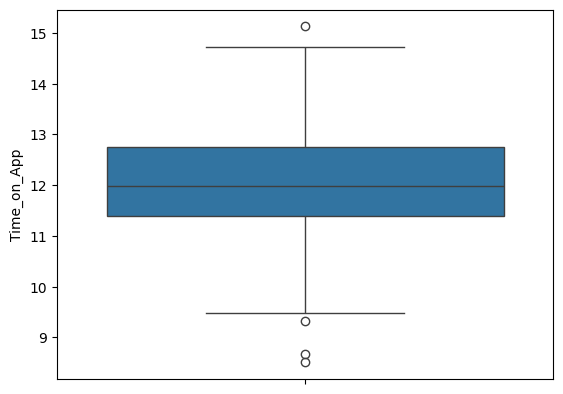

In [104]:

sns.boxplot(df['Time_on_App'])
plt.show()

In [105]:
df_cleaned = df.copy()


(1.3549999999999986, 9.365000000000002, 14.784999999999997)

Time_on_App ([], [])
(1.365000000000002, 34.30499999999999, 39.765)

Time_on_Website ([], [])
(1.1625, 1.2137499999999999, 5.8637500000000005)
214 : 1.14
320 : 1.2

Length_of_Membership ([], [1.14, 1.2])
(102.31499999999994, 292.6125000000001, 701.8725)

Yearly_Amount_Spent ([], [])


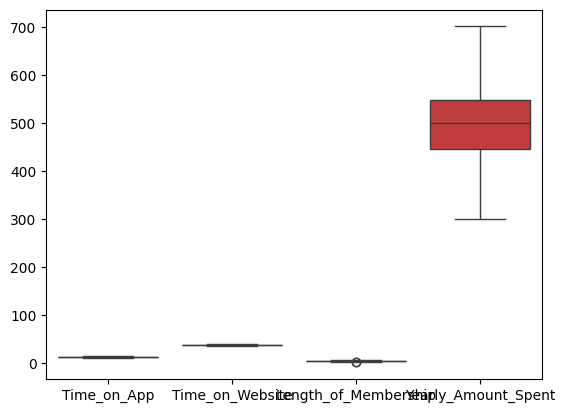

In [106]:
# lets drop outliers
for i in df_cleaned.select_dtypes('number').columns:
    df_cleaned[i] = handler.fit_transform_IQR(df_cleaned[i])

for i in df_cleaned.select_dtypes('number').columns:
    print(handler.fit_IQR(df_cleaned[i]))
    print(f'\n{i:}',handler.display_outliers(df_cleaned[i]))

sns.boxplot(df_cleaned)
plt.show()

In [107]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Time_on_App           496 non-null    float64
 4   Time_on_Website       498 non-null    float64
 5   Length_of_Membership  488 non-null    float64
 6   Yearly_Amount_Spent   491 non-null    float64
dtypes: float64(4), object(3)
memory usage: 27.5+ KB


### preprocessing
    scale data, dimensionality reduction


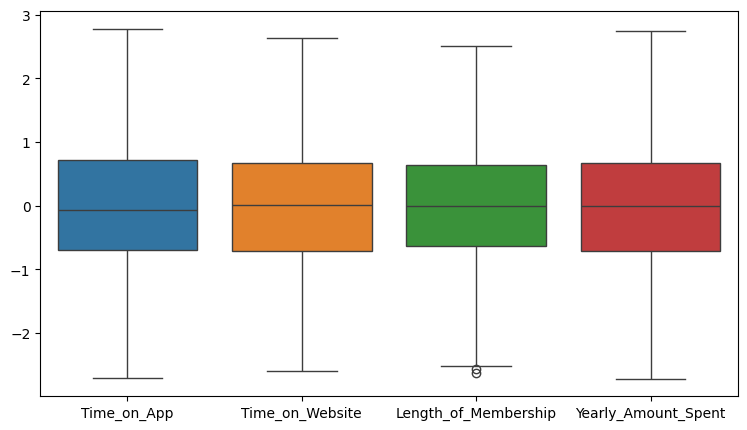

In [108]:
# now its time to scale the data
scaler = StandardScaler()


df_scaled = scaler.fit_transform(df_cleaned.select_dtypes('number'))
df_scaled = pd.DataFrame(df_scaled, columns=df_cleaned.select_dtypes('number').columns)

plt.figure(figsize=(9,5))
sns.boxplot(df_scaled)

plt.show()

In [109]:
print(df_scaled.isna().sum())
df_scaled.dropna(inplace=True)

Time_on_App              4
Time_on_Website          2
Length_of_Membership    12
Yearly_Amount_Spent      9
dtype: int64


In [110]:
df_scaled.isna().sum()

Time_on_App             0
Time_on_Website         0
Length_of_Membership    0
Yearly_Amount_Spent     0
dtype: int64

In [111]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 479 entries, 0 to 499
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Time_on_App           479 non-null    float64
 1   Time_on_Website       479 non-null    float64
 2   Length_of_Membership  479 non-null    float64
 3   Yearly_Amount_Spent   479 non-null    float64
dtypes: float64(4)
memory usage: 18.7 KB


### lets do the clustering

1844.7889997702855
1304.7015534090183
1117.534220755571
944.3705278264654
801.2640249288612
711.3235687912894
651.9998878251098
616.4450607173201
558.1339719536447
521.9966312052117


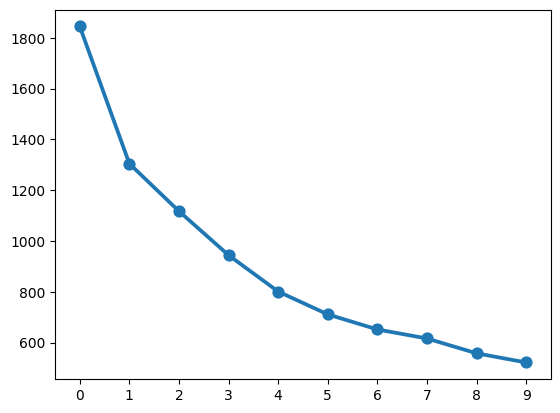

In [134]:
# elbow method
from sklearn.cluster import KMeans 
intertia_list = []
for i in range(1,11):
    k_means = KMeans(n_clusters=i, random_state= 42)
    intertia = k_means.fit(df_scaled).inertia_
    print(intertia)
    intertia_list.append(intertia)
# plt.plot(intertia_list)
sns.pointplot(intertia_list)
plt.show()

## based on the graph above i decided to use 4 clusters